In [1]:
import torch
from torch.utils import data
from tcn import TCN, BranchedTCN, BranchedTCN_CE
import dataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics import precision_score, recall_score
import config
import os

# Get GPU if possible, else get CPU
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU! Using CPU only")

Using the GPU!


### Prepare For Evaluation
#### Grab the evaluation dataloaders

In [2]:
dl = dataLoader.get_dataloaders(data_dir=config.data_dir, 
                                batch_size=128, 
                                max_range=config.max_range, 
                                shuffle=False, 
                                transform=dataLoader.get_image_transforms(),
                                squeeze=True,
                                hpf=True)

#### Load the desired model checkpoint

In [2]:
model = BranchedTCN_CE(input_size=232, output_size=2, num_channels=[368]*9, kernel_size=6, dropout=0.35, softmax=True).to(device)
#model = BranchedTCN(input_size=232, output_size=2, num_channels=[368]*9, kernel_size=6, dropout=0.35).to(device)
#model = TCN(input_size=232, output_size=2, num_channels=[368]*9, kernel_size=6, dropout=0.35).to(device)
model.load_state_dict(torch.load(os.path.join(config.models_dir + '/L2NormFixLoss2', 'weights_100.pt'), map_location=device)['model_state_dict'])

<All keys matched successfully>

### Evaluate Model On Synthetic Data
#### Get Predictions and Labels

In [3]:
def evaluate_model(model, dataloader, thresh=0.5, save_data=False):
    
    """
    Get predicted and ground truth values for range and class using a given model and dataloader
    
    Parameters
    ----------
    model: nn.Module, input model to be evaluated
    dataloader: torch.utils.data.DataLoader, dataloader for dataset to be used to evaluate model
    
    Returns
    -------
    ranges_p: array-like, predicted ranges
    ranges_t array-like, true classes
    class_p: array-like, predicted ranges
    class_t: array-like, true classes
    """
    
    # Put model in eval mode
    model.eval()
    
    # Store true labels
    ranges_t = []
    ranges_p = []
    class_t = []
    class_p = []
    # snr_t = []
    outputs_all = []
    
    # Store data
    X = []
    
    for inputs, r_labels, c_labels in tqdm(dataloader):

        inputs = inputs.to(device)
        r_labels = r_labels.to(device).squeeze()
        c_labels = c_labels.to(device).squeeze()

        with torch.set_grad_enabled(False):

            outputs = model(inputs)
            outputs_all += outputs.detach().tolist()
            ranges_p += (outputs[:,0].squeeze()*config.max_range).detach().tolist()
            ranges_t += (r_labels.squeeze()*config.max_range).detach().tolist()
            class_p += (outputs[:,2] >= thresh).tolist()
            class_t += c_labels.tolist()
            # snr_t += snr_labels.tolist()
            if save_data:
                X += inputs.tolist()

    ranges_p = np.asarray(ranges_p)
    ranges_t = np.asarray(ranges_t)
    ranges_t[ranges_t < 0] = -1
    class_p = np.asarray(class_p)
    class_t = np.asarray(class_t)
    # snr_t = np.asarray(snr_t)
    outputs_all = np.asarray(outputs_all)
    X = np.asarray(X)
    
    return ranges_p, ranges_t, class_p, class_t, outputs_all, X

In [5]:
# evaluate
ranges_p, ranges_t, class_p, class_t, _, _, snr_t = evaluate_model(model, dl['test'], thresh=0.5, save_data=False)

# get some stats
p = precision_score(class_t, class_p)
r = recall_score(class_t, class_p)
a = (class_t == class_p).sum() / len(class_t)
print("Accuracy: {:.4f}\nPrecision: {:.4f}\nRecall: {:.4f}".format(a, p, r))

  0%|          | 0/577 [00:00<?, ?it/s]

Accuracy: 0.9921
Precision: 0.9984
Recall: 0.9858


#### Plot Predicted Ranges of Detections Vs. Ground Truth

In [4]:
def plot_true_pred(ranges_t, ranges_p, class_t, class_p, markersize=1, save=False, gt_type='sim'):
    
    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    plt.plot(ranges_t, ranges_p, 'o', markersize=markersize, label="range predictions")
    plt.plot([0, config.max_range], [0, config.max_range], '--r', label="ideal mapping")
    plt.grid()
    plt.legend()
    if gt_type == 'sim':
        plt.xlabel("True Range [m]")
        plt.ylabel("Predicted Range [m]")
    elif gt_type == 'exp':
        plt.xlabel("Warping-Based Range Estimation [m]")
        plt.ylabel("TCN-Based Range Estimation [m]")
    else:
        raise ValueError("gt_type must be either 'sim' or 'exp'")
        
    if save:
        plt.savefig(config.data_dir + '/predvact.jpg', format='jpg')
    plt.show()
    
    MSE = ((ranges_t - ranges_p) ** 2).mean()
    RMSE = np.sqrt(MSE)
    MAPE = (np.abs(ranges_t - ranges_p) / ranges_t).mean()
    MAE = np.abs(ranges_t - ranges_p).mean()
    
    print("MSE: {:.3f} m".format(MSE))
    print("RMSE: {:.3f} m".format(RMSE))
    print("MAPE: {:.4f}".format(MAPE))
    print("MAE: {:.3f} m".format(MAE))

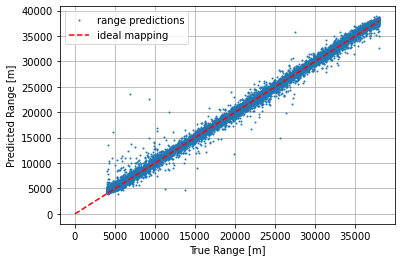

MSE: 231007.706 m
RMSE: 480.633 m
MAPE: 0.0198
MAE: 294.172 m


In [109]:
plot_true_pred(ranges_t, ranges_p, class_t, class_p, save=True)

#### Plot Intra-Range Standard Deviation + Error

In [5]:
def plot_intra_range_std(ranges_t, ranges_p, class_t, class_p, save=False):

    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get standard deviation of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    std_list = [np.std(ranges_p[ranges_t == r]) for r in unique_ranges]
    
    plt.plot(unique_ranges, std_list)
    plt.grid()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("STD of Predicted Ranges [m]")
    if save:
        plt.savefig(config.data_dir + '/std.eps', format='eps')
    plt.show()
    
    return std_list

def plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list, save=False):
    
    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get average error of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    avg_err = [np.mean(r - ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, avg_err, label="Average Error")
    plt.fill_between(np.asarray(unique_ranges), np.asarray(avg_err) - 2*np.asarray(std_list), np.asarray(avg_err) + 2*np.asarray(std_list), alpha=0.3, label="$\pm2\sigma$")
    plt.grid()
    plt.legend()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("Average Error of Predicted Ranges [m]")
    if save:
        plt.savefig(config.data_dir + '/errstd.pdf', format='pdf')
    plt.show()

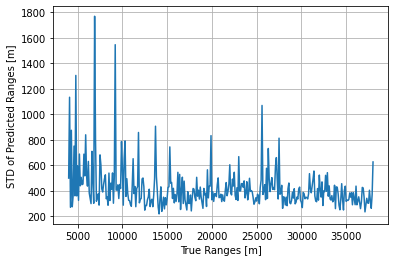

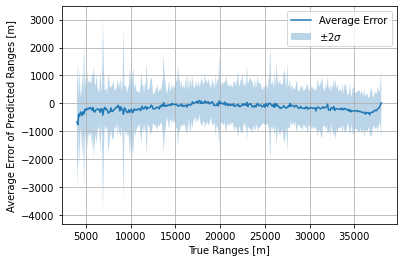

In [68]:
std_list = plot_intra_range_std(ranges_t, ranges_p, class_t, class_p, save=False)
plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list, save=True)

#### Error vs. SNR

In [6]:
def err_v_snr(ranges_t, ranges_p, class_t, class_p, dataset, snr_t, k=16, dim=(4,4)):
    
    # isolate true positives
    ranges_calls_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_calls_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    snr_t = snr_t.squeeze()
    snr_calls_t = snr_t[np.where((class_p == 1) & (class_t == 1))]
    dataset = dataset[np.where((class_p == 1) & (class_t == 1))[0],...]
    
    # Get indices of top-k highest-error calls
    abs_err = np.abs(ranges_calls_t - ranges_calls_p)
    e_thresh = 1000
    snr_calls_t = snr_calls_t[abs_err > e_thresh]
    abs_err = abs_err[abs_err > e_thresh]
    (n, bins, patches) = plt.hist(snr_calls_t, edgecolor='black',bins=3)
    print(n)
    print(bins)
    plt.xlabel('SNR')
    plt.ylabel('Calls with Absolute Error > {} m'.format(e_thresh))

[460. 380. 291.]
[-10.9979105   -9.66535346  -8.33279641  -7.00023937]


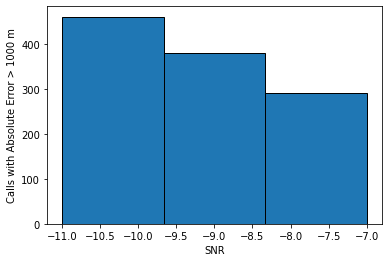

In [152]:
err_v_snr(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'], snr_t)

#### Display Top-k Highest Error Calls

In [7]:
def display_high_error(ranges_t, ranges_p, class_t, class_p, dataset, k=16, dim=(4,4)):
    
    # isolate true positives
    ranges_calls_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_calls_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    dataset = dataset[np.where((class_p == 1) & (class_t == 1))[0],...]
    
    # Get indices of top-k highest-error calls
    top_k_abs_err = np.abs(ranges_calls_t - ranges_calls_p)
    inds = top_k_abs_err.argsort()[::-1][:k]
    
    # Get error values and correspinding spectrograms
    top_k_abs_err = top_k_abs_err[inds]
    top_k_err_X = dataset[inds, ...]
    range_calls_t_filt = ranges_calls_t[inds]
    
    import plotter
    plotter.plot_grid(top_k_err_X, top_k_abs_err, label_text="Err:", title="High Error Calls", dim=dim, randomize=False)

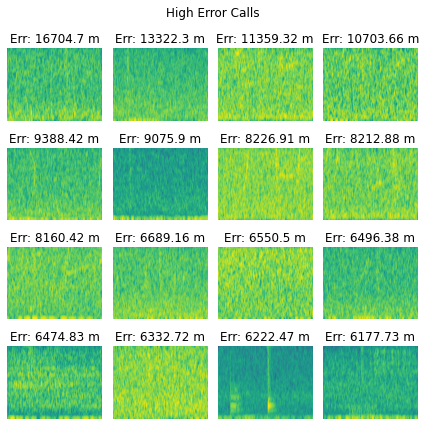

In [134]:
display_high_error(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'])

#### Plot False Negatives

In [8]:
def display_FNs(ranges_t, ranges_p, class_t, class_p, dataset, k=16, dim=(4,4)):
    ranges_calls_t = ranges_t[np.where((class_p == 0) & (class_t == 1))]
    ranges_calls_p = ranges_p[np.where((class_p == 0) & (class_t == 1))]
    dataset = dataset[np.where((class_p == 0) & (class_t == 1))[0],...]
    print(max(ranges_calls_t))
    
    import plotter
    plotter.plot_grid(dataset, ranges_calls_p, label_text="Range_p:", title="FNs", dim=dim, sub_titles=False, randomize=False)

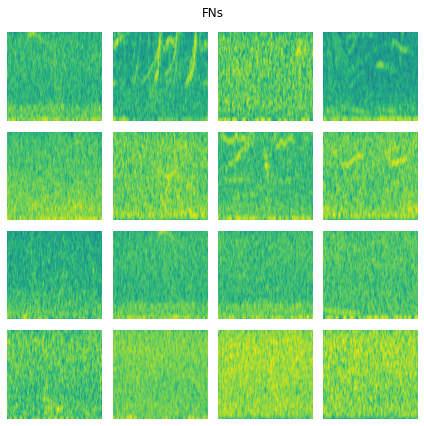

In [57]:
display_FNs(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'])

#### Plot False Negatives

In [9]:
def display_FPs(ranges_t, ranges_p, class_t, class_p, dataset, k=16, dim=(4,4)):
    
    ranges_calls_t = ranges_t[np.where((class_p == 1) & (class_t == 0))]
    ranges_calls_p = ranges_p[np.where((class_p == 1) & (class_t == 0))]
    dataset = dataset[np.where((class_p == 1) & (class_t == 0))[0],...]
    
    import plotter
    plotter.plot_grid(dataset, ranges_calls_p, label_text="Range_p:", title="FPs", dim=dim, sub_titles=False, randomize=False)

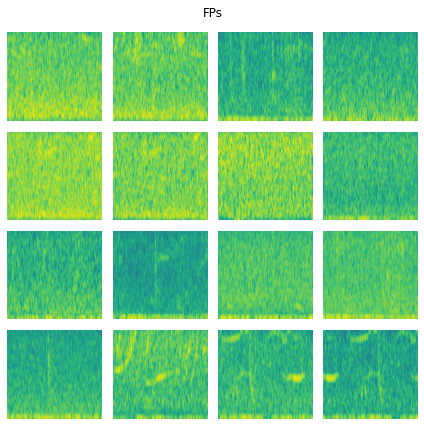

In [59]:
display_FPs(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'])

### Evaluate Model On Experimental Data
#### Put Warped Data Into A Dataloader

In [10]:
warp_dataset = dataLoader.Warped(dir_path=config.exp_data, 
                                 max_range=config.max_range, 
                                 transform=dataLoader.get_image_transforms()['eval'], 
                                 squeeze=True,
                                 hpf=False)

warp_dl = {'test': data.DataLoader(warp_dataset, batch_size=5, shuffle=False)}

#### Evalutate Model On Experimental Data

In [11]:
# evaluate the model
warp_ranges_p, warp_ranges_t, warp_class_p, warp_class_t, outputs, X = evaluate_model(model, warp_dl['test'], thresh=0.5, save_data=True)

# filter so that true ranges are within the bounds of the training data
inds = np.where((warp_ranges_t <= config.max_range) & (warp_ranges_t >= config.min_range) & (warp_ranges_t != -1))
inds_fnfp = np.where(((warp_ranges_t <= config.max_range) & (warp_ranges_t >= config.min_range)) | (warp_ranges_t == -1))
# Filter out calls within range of trining data and the noise examples
acc_inds = np.where(((warp_ranges_t <= config.max_range) & (warp_ranges_t >= config.min_range)) | (warp_ranges_t == -1))

# get calls in range of training data
warp_ranges_p_filt = warp_ranges_p[inds[0]] 
warp_class_t_filt = warp_class_t[inds[0]] 
warp_class_p_filt = warp_class_p[inds[0]]
warp_ranges_t_filt = warp_ranges_t[inds[0]]
dataset = warp_dl['test'].dataset.inputs['data']
dataset_filt = dataset[inds[0],...]
print(f"{warp_class_p_filt.sum()} / {warp_class_t_filt.sum()} calls detected")

# Get some stats with in-range calls and noise examples
p = precision_score(warp_class_t[acc_inds[0]], warp_class_p[acc_inds[0]])
r = recall_score(warp_class_t[acc_inds[0]], warp_class_p[acc_inds[0]])
a = (warp_class_t[acc_inds[0]] == warp_class_p[acc_inds[0]]).sum() / len(warp_class_t[acc_inds[0]])
print("Accuracy: {:.4f}\nPrecision: {:.4f}\nRecall: {:.4f}".format(a, p, r))

  0%|          | 0/22 [00:00<?, ?it/s]

40 / 50.0 calls detected
Accuracy: 0.9000
Precision: 1.0000
Recall: 0.8000


#### Plot Predicted Ranges of Detections Vs. Ground Truth

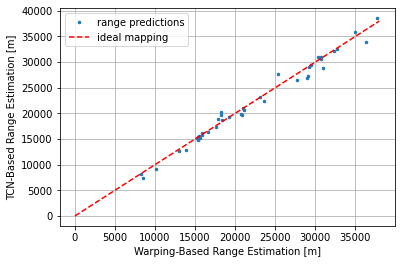

MSE: 1081359.829 m
RMSE: 1039.885 m
MAPE: 0.0353
MAE: 743.938 m


In [12]:
plot_true_pred(warp_ranges_t_filt, warp_ranges_p_filt, warp_class_t_filt, warp_class_p_filt, markersize=2.5, save=True, gt_type='exp')

#### Display Top-k Highest Error Calls

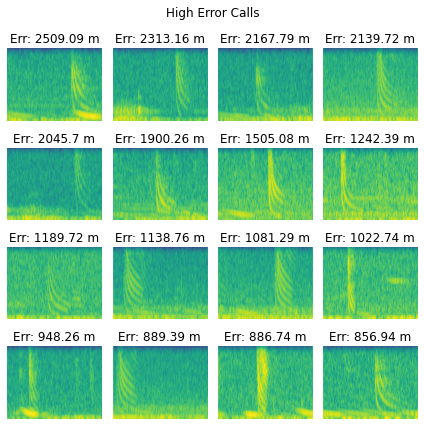

In [44]:
display_high_error(warp_ranges_t_filt, warp_ranges_p_filt, warp_class_t_filt, warp_class_p_filt, dataset_filt)

#### Display False Negatives

25700.0


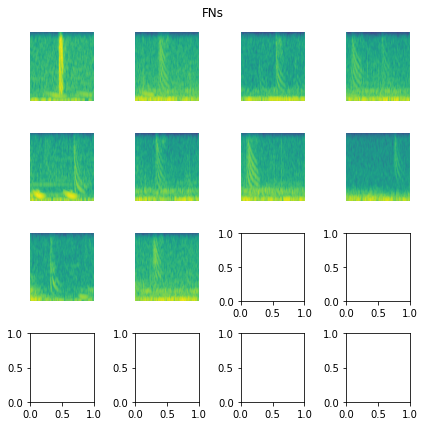

In [42]:
display_FNs(warp_ranges_t[inds_fnfp[0]], warp_ranges_p[inds_fnfp[0]], warp_class_t[inds_fnfp[0]], warp_class_p[inds_fnfp[0]], dataset[inds_fnfp[0]])

#### Display False Positives

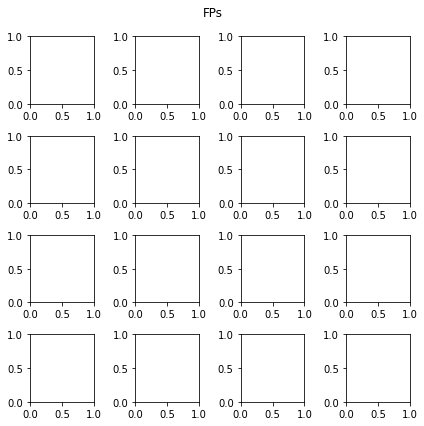

In [46]:
display_FPs(warp_ranges_t[inds_fnfp[0]], warp_ranges_p[inds_fnfp[0]], warp_class_t[inds_fnfp[0]], warp_class_p[inds_fnfp[0]], dataset[inds_fnfp[0]])

#### Display Missed/Detected Calls

In [69]:
def display_missed_detected(ranges_t, ranges_p, class_t, class_p, dataset, range_lims, randomize=False):
    from dataLoader import to_spect
    # Missed Calls
    ranges_t_miss = ranges_t[np.where((class_p == 0) & (class_t == 1) & (ranges_t >= range_lims[0]) & (ranges_t < range_lims[1]))]
    dataset_miss = dataset[np.where((class_p == 0) & (class_t == 1) & (ranges_t >= range_lims[0]) & (ranges_t < range_lims[1]))[0],...]
    
    if len(dataset_miss.shape) == 2:
        dataset_miss = to_spect(dataset_miss)
    
    print(dataset_miss.shape)
    
    if randomize:
        dataset_miss = dataset_miss[np.random.choice(3,3,replace=False)]
    
    if len(dataset_miss) > 1:    
        fig1, axes1 = plt.subplots(1, len(dataset_miss), figsize=(6,6))
        axes1 = axes1.flatten()
        i = 0
        for img, ax in zip(dataset_miss, axes1):
            ax.imshow(np.squeeze(img), aspect='equal')
            ax.axis('off')
            ax.set_aspect(601/232)
            i += 1
        #plt.tight_layout()
        plt.subplots_adjust(top = 0.6, bottom=0.1, hspace=0.01, wspace=0.07)
        plt.show()
    elif len(dataset_miss) == 1:
        plt.imshow(np.squeeze(dataset_miss), aspect=601/232)
        plt.axis('off')
        plt.show()
    else:
        raise ValueError('No calls in specified range bounds.')
    
#     # Detected Calls
#     ranges_t_hit = ranges_t[np.where((class_p == 1) & (class_t == 1) & (ranges_t >= range_lims[0]) & (ranges_t < range_lims[1]))]
#     dataset_hit = dataset[np.where((class_p == 1) & (class_t == 1) & (ranges_t >= range_lims[0]) & (ranges_t < range_lims[1]))[0],...]

#     if len(dataset_hit.shape) == 2:
#         dataset_hit = to_spect(dataset_hit)
#     print(dataset_hit.shape)
#     if randomize:
#         dataset_hit = dataset_hit[np.random.choice(3,3,replace=False)]
#     print(dataset_hit.shape)
#     if len(dataset_hit) > 1:    
#         fig1, axes1 = plt.subplots(1, 3, figsize=(6,6))
#         axes1 = axes1.flatten()
#         i = 0
#         for img, ax in zip(dataset_hit, axes1):
#             ax.imshow(np.squeeze(img), aspect='equal')
#             ax.axis('off')
#             ax.set_aspect(601/232)
#             i += 1
#         #plt.tight_layout()
#         plt.subplots_adjust(top = 0.6, bottom=0.1, hspace=0.01, wspace=0.07)
#         plt.show()
#     elif len(dataset_hit) == 1:
#         plt.imshow(np.squeeze(dataset_hit), aspect=601/232)
#         plt.axis('off')
#         plt.show()
#     else:
#         raise ValueError('No calls in specified range bounds.')

In [70]:
inter = (config.max_range - config.min_range) / 3

display_missed_detected(warp_ranges_t[inds_fnfp[0]], warp_ranges_p[inds_fnfp[0]], warp_class_t[inds_fnfp[0]], warp_class_p[inds_fnfp[0]], dataset[inds_fnfp[0]], [config.min_range + (2*inter), config.max_range], randomize=True)

(0, 1, 3600)


IndexError: index 1 is out of bounds for axis 0 with size 0

#### Classification Threshold Sweeping Analysis

In [23]:
def class_thresh_sweep(outputs, warp_ranges_t, warp_class_t, save=False):
    
    # Get precision-recall curve
    from sklearn.metrics import precision_recall_curve, auc
    precision, recall, thresholds = precision_recall_curve(warp_class_t, outputs[:,2])
    
    # Initialize lists for range statistics
    RMSE, MAPE, MAE = [], [], []
    num_detected = []
    
    for t in thresholds:
        
        # Get true and predicted ranges for detected calls at each threshold
        ranges_t = []
        ranges_p = []
        for prob, label, rp, rt in zip(outputs[:,2], warp_class_t, outputs[:,0], warp_ranges_t):
            if prob >= t and label == 1:
                ranges_t.append(rt)
                ranges_p.append(rp*config.max_range)
        ranges_t = np.asarray(ranges_t)
        ranges_p = np.asarray(ranges_p)
        
        # Calculate range statistics if there were calls detected
        if len(ranges_t) > 0:
            mse = ((ranges_t - ranges_p) ** 2).mean()
            rmse = np.sqrt(mse)
            mape = (np.abs(ranges_t - ranges_p) / ranges_t).mean()
            mae = np.abs(ranges_t - ranges_p).mean()

            RMSE.append(rmse)
            MAPE.append(mape*100)
            MAE.append(mae)
            num_detected.append((len(ranges_t)/50))
        else:
            import warnings
            warnings.warn("At least one threshold setting resulted in zero detections.")
    
    # Plot PRC
    plt.figure()
    area_uc = auc(recall, precision)
    plt.plot(recall, precision, '-o', label='TCN (AUC = {:.2f})'.format(area_uc), markersize=4)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid()
    plt.legend()
    if save:
        plt.savefig(config.data_dir + '/prc.eps', format='eps')
    plt.show()
    
    # Plot range statistics
    plt.figure()
    ax1 = plt.subplot()
    l1, = ax1.plot(num_detected, RMSE, 'bo-', markersize=4)
    l2, = ax1.plot(num_detected, MAE, 'b*--', markersize=4)
    ax2 = ax1.twinx()
    l3, = ax2.plot(num_detected, MAPE, 'rx-')
    ax1.tick_params(axis='y', colors='blue')
    ax1.spines["left"].set_edgecolor('blue')
    ax1.set_xlabel("Recall")
    ax1.set_ylabel("Range Error [m]", color='blue')
    ax2.set_ylabel("Mean Absolute Percent Error [%]", color='red')
    ax2.tick_params(axis='y', colors='red')
    ax1.grid(True)
    ax1.set_ylim([500,7500])
    ax2.set_ylim([2,30])
    ax1.set_yticks(np.linspace(ax1.get_ybound()[0], ax1.get_ybound()[1], 8))
    ax2.set_yticks(np.linspace(ax2.get_ybound()[0], ax2.get_ybound()[1], 8))
    plt.legend([l1, l2, l3], ["RMSE", "MAE", "MAPE"], loc='upper left')
    if save:
        plt.savefig(config.data_dir + '/rangethresh.eps', format='eps')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


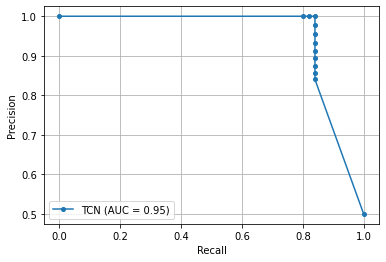

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


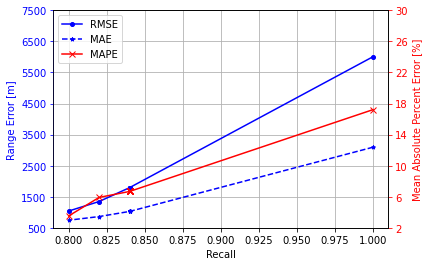

In [24]:
class_thresh_sweep(outputs[inds_fnfp[0],...], warp_ranges_t[inds_fnfp[0]], warp_class_t[inds_fnfp[0]], save=True)